# 🎯 Analyse Exploratoire des Données (EDA)
## Projet : Prédiction du Churn Client - Télécoms

### Objectif
Ce notebook a pour but d'explorer et de comprendre le dataset de churn client.
Nous allons répondre aux questions suivantes :
- Combien de clients ont churné ?
- Quelles sont les caractéristiques des clients qui partent ?
- Quelles variables sont les plus liées au churn ?

### Dataset
**Source** : IBM Telco Customer Churn (Kaggle)  
**Volume** : 7 043 clients, 21 variables  
**Cible** : Variable `Churn` (Yes/No)

In [1]:
# =============================================================
# IMPORTS DES BIBLIOTHÈQUES
# =============================================================

# pandas : manipulation de données sous forme de tableaux
import pandas as pd

# numpy : calculs mathématiques
import numpy as np

# matplotlib et seaborn : visualisation de données (graphiques)
import matplotlib.pyplot as plt
import seaborn as sns

# Paramètres d'affichage des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Afficher toutes les colonnes dans les tableaux
pd.set_option('display.max_columns', None)

print(" Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


## 1. Chargement des Données

On charge le fichier CSV dans un **DataFrame** pandas.  

On vérifie ensuite :
- La taille du dataset (nombre de lignes et colonnes)
- Les premières lignes pour voir à quoi ressemblent les données

In [2]:
# =============================================================
# CHARGEMENT DES DONNÉES
# =============================================================

# On charge le fichier CSV depuis le dossier data/raw/
df = pd.read_csv('../data/raw/telco_churn.csv')

# On affiche la taille du dataset
print(f" Nombre de clients : {df.shape[0]}")
print(f" Nombre de variables : {df.shape[1]}")
print(f"\n Premières lignes du dataset :")

# On affiche les 5 premières lignes
df.head()

📊 Nombre de clients : 7043
📋 Nombre de variables : 21

🔍 Premières lignes du dataset :


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploration Initiale

On va maintenant examiner la structure du dataset :
- Les types de chaque colonne (texte, nombre, etc.)
- Les valeurs manquantes
- Les statistiques de base (moyenne, min, max, etc.)

In [3]:
# =============================================================
# STRUCTURE DU DATASET
# =============================================================

print(" INFORMATIONS GÉNÉRALES SUR LE DATASET")
print("=" * 50)
df.info()

📋 INFORMATIONS GÉNÉRALES SUR LE DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pa

In [4]:
# =============================================================
# VÉRIFICATION DES VALEURS MANQUANTES
# =============================================================

# On compte les valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()

# On affiche uniquement les colonnes qui ont des valeurs manquantes
print(" Colonnes avec des valeurs manquantes :")
print(valeurs_manquantes[valeurs_manquantes > 0])

print(f"\n Total de valeurs manquantes : {df.isnull().sum().sum()}")

❌ Colonnes avec des valeurs manquantes :
Series([], dtype: int64)

✅ Total de valeurs manquantes : 0


## 3. Statistiques Descriptives

On regarde les statistiques de base des colonnes numériques :
- **count** : nombre de valeurs
- **mean** : moyenne
- **min / max** : valeurs minimale et maximale
- **std** : écart-type (mesure la dispersion des valeurs)

In [5]:
# =============================================================
# STATISTIQUES DESCRIPTIVES
# =============================================================

# Statistiques des colonnes numériques
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Vérification des valeurs distinctes de SeniorCitizen
print("Valeurs distinctes de SeniorCitizen :")
print(df['SeniorCitizen'].unique())

print(f"\nNombre de valeurs distinctes : {df['SeniorCitizen'].nunique()}")

print("\nDistribution :")
print(df['SeniorCitizen'].value_counts())

Valeurs distinctes de SeniorCitizen :
[0 1]

Nombre de valeurs distinctes : 2

Distribution :
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


La variable **TotalCharges** représente un montant d'argent, elle devrait être numérique comme **MonthlyCharges**. Vérifions pourquoi elle est en object.

In [7]:
# Vérification de la colonne TotalCharges
print("Type actuel :", df['TotalCharges'].dtype)

print("\nQuelques valeurs :")
print(df['TotalCharges'].head(10))

print("\nValeurs non convertibles en nombre :")
# On essaie de convertir en nombre, les erreurs deviennent NaN
test = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df[test.isnull()]['TotalCharges'].value_counts())
print(f"Nombre de valeurs problématiques : {test.isnull().sum()}")

Type actuel : object

Quelques valeurs :
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

Valeurs non convertibles en nombre :
TotalCharges
    11
Name: count, dtype: int64
Nombre de valeurs problématiques : 11


On voit qu'il y a 11 valeurs qui ne peuvent pas être converties en nombre, elles contiennent probablement des espaces vides au lieu d'un vrai nombre.

In [8]:
# On identifie exactement les 11 lignes problématiques
test = pd.to_numeric(df['TotalCharges'], errors='coerce')
lignes_problematiques = df[test.isnull()]

print(f"Les 11 lignes problématiques :")
print(lignes_problematiques[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Les 11 lignes problématiques :
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


Tous ces clients ont tenure = 0 ce qui veut dire qu'ils viennent juste d'arriver, ils n'ont pas encore payé un seul mois. Donc leur TotalCharges est vide au lieu de 0. C'est logique car pas d'ancienneté = pas de total de charges !

In [9]:
# =============================================================
# CORRECTION DE LA COLONNE TotalCharges
# =============================================================

#Convertir en nombre (les espaces vides deviennent NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Remplacer les NaN par 0 (logique : tenure=0 donc charges=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Vérification
print(f"Nouveau type : {df['TotalCharges'].dtype}")
print(f"Valeurs manquantes restantes : {df['TotalCharges'].isnull().sum()}")
print(f"\nLes 11 clients corrigés :")
print(df.loc[[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], 
             ['customerID', 'tenure', 'TotalCharges']])

Nouveau type : float64
Valeurs manquantes restantes : 0

Les 11 clients corrigés :
      customerID  tenure  TotalCharges
488   4472-LVYGI       0           0.0
753   3115-CZMZD       0           0.0
936   5709-LVOEQ       0           0.0
1082  4367-NUYAO       0           0.0
1340  1371-DWPAZ       0           0.0
3331  7644-OMVMY       0           0.0
3826  3213-VVOLG       0           0.0
4380  2520-SGTTA       0           0.0
5218  2923-ARZLG       0           0.0
6670  4075-WKNIU       0           0.0
6754  2775-SEFEE       0           0.0


## 4. Analyse de la Variable Cible : Churn

On regarde combien de clients ont churné vs ceux qui sont restés.

Si les proportions sont très déséquilibrées, le modèle ML aura du mal à apprendre alors on devra le corriger plus tard.

📊 Distribution du Churn :
  ✅ Non-Churn : 5174 clients (73.5%)
  ❌ Churn     : 1869 clients (26.5%)


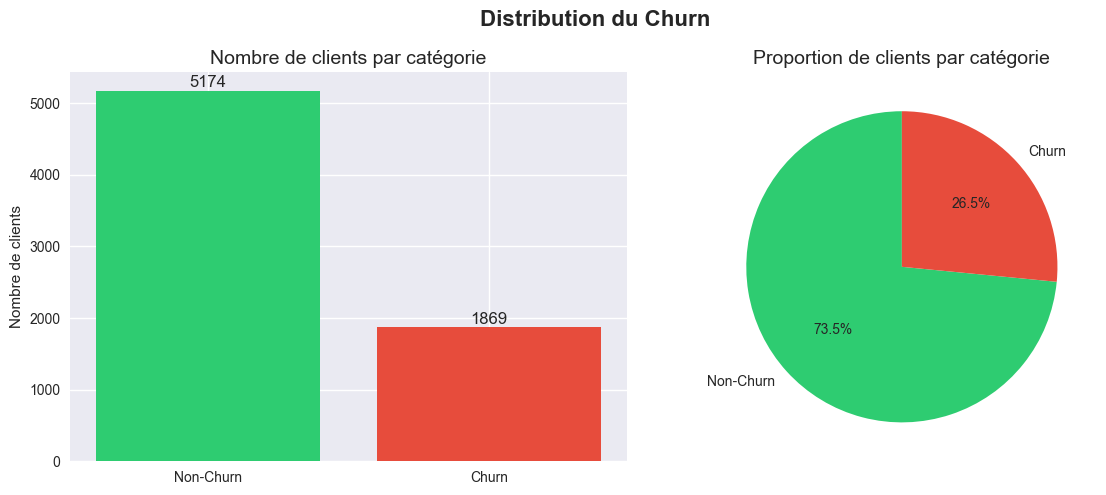

In [10]:
# =============================================================
# DISTRIBUTION DU CHURN
# =============================================================

# Compter le nombre de churners vs non-churners
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(" Distribution du Churn :")
print(f"   Non-Churn : {churn_counts['No']} clients ({churn_pct['No']:.1f}%)")
print(f"   Churn     : {churn_counts['Yes']} clients ({churn_pct['Yes']:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : barres
axes[0].bar(['Non-Churn', 'Churn'],
            churn_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Nombre de clients par catégorie', fontsize=14)
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

# Graphique 2 : camembert
axes[1].pie(churn_counts.values,
            labels=['Non-Churn', 'Churn'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Proportion de clients par catégorie', fontsize=14)

plt.suptitle('Distribution du Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

On voit qu'il y a 3 fois plus de non-churners que de churners. L'entreprise perd donc 1 client sur 4 chaque année, ce qui est énorme.
Sachant que garder un client coûte 5x moins cher que d'en trouver un nouveau, alors si on prédit qui va partir 3 mois avant, on peut leur proposer une offre spéciale pour les retenir. 

##  6. Analyse Bivariée 

- On analyse les types de clients qui partent en fonction de leurs types de contrat.
- On analyse si les nouveaux clients partent plus que les anciens.


📋 Taux de churn par type de contrat :
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


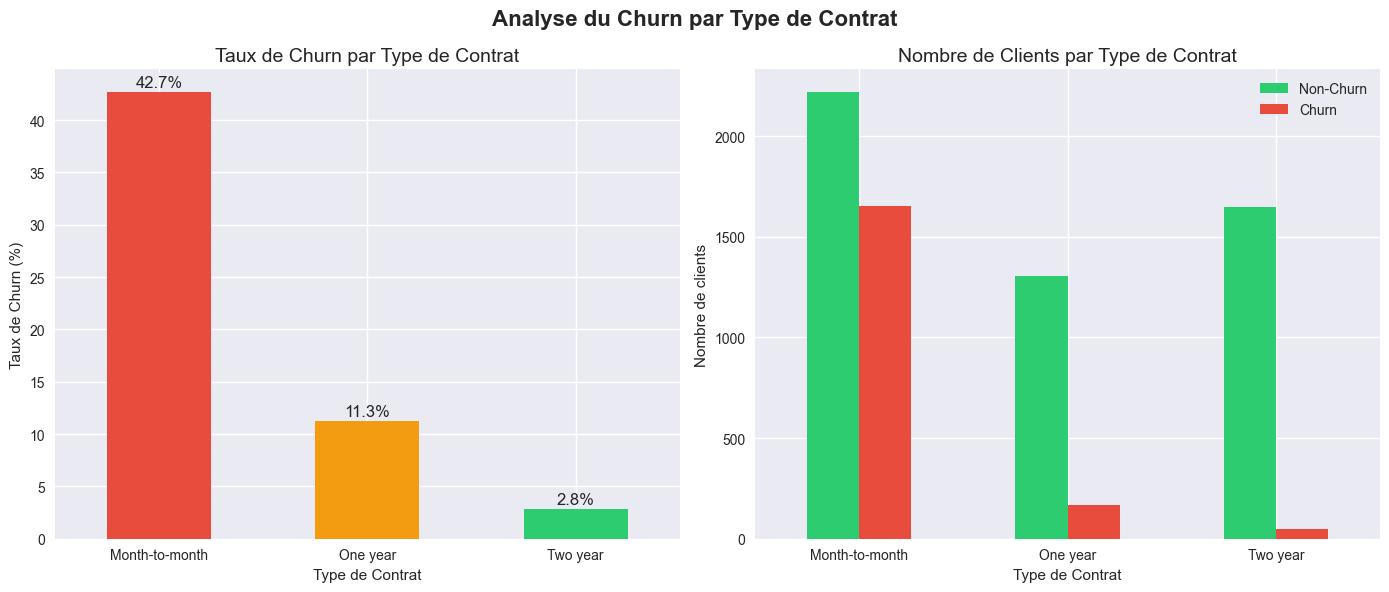

In [11]:
# =============================================================
# CHURN PAR TYPE DE CONTRAT
# =============================================================

# Compter le churn par type de contrat
contrat_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

print(" Taux de churn par type de contrat :")
print(contrat_churn.round(1))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : taux de churn par contrat
contrat_churn['Yes'].plot(kind='bar', 
                           ax=axes[0],
                           color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0].set_title('Taux de Churn par Type de Contrat', fontsize=14)
axes[0].set_xlabel('Type de Contrat')
axes[0].set_ylabel('Taux de Churn (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(contrat_churn['Yes']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

# Graphique 2 : nombre de clients par contrat
df.groupby(['Contract', 'Churn']).size().unstack().plot(
    kind='bar',
    ax=axes[1],
    color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Nombre de Clients par Type de Contrat', fontsize=14)
axes[1].set_xlabel('Type de Contrat')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Non-Churn', 'Churn'])

plt.suptitle('Analyse du Churn par Type de Contrat', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Les clients sans engagement (mois par mois) partent massivement, presque 1 sur 2 tandis que les clients avec un contrat de 2 ans sont presque tous fidèles, seulement 2.8% partent. L'engagement contractuel est probablement un facteur du churn.

L'entreprise devrait songé à proposer des incentives pour pousser les clients month-to-month vers des contrats plus longs (réduction, avantages, etc.)

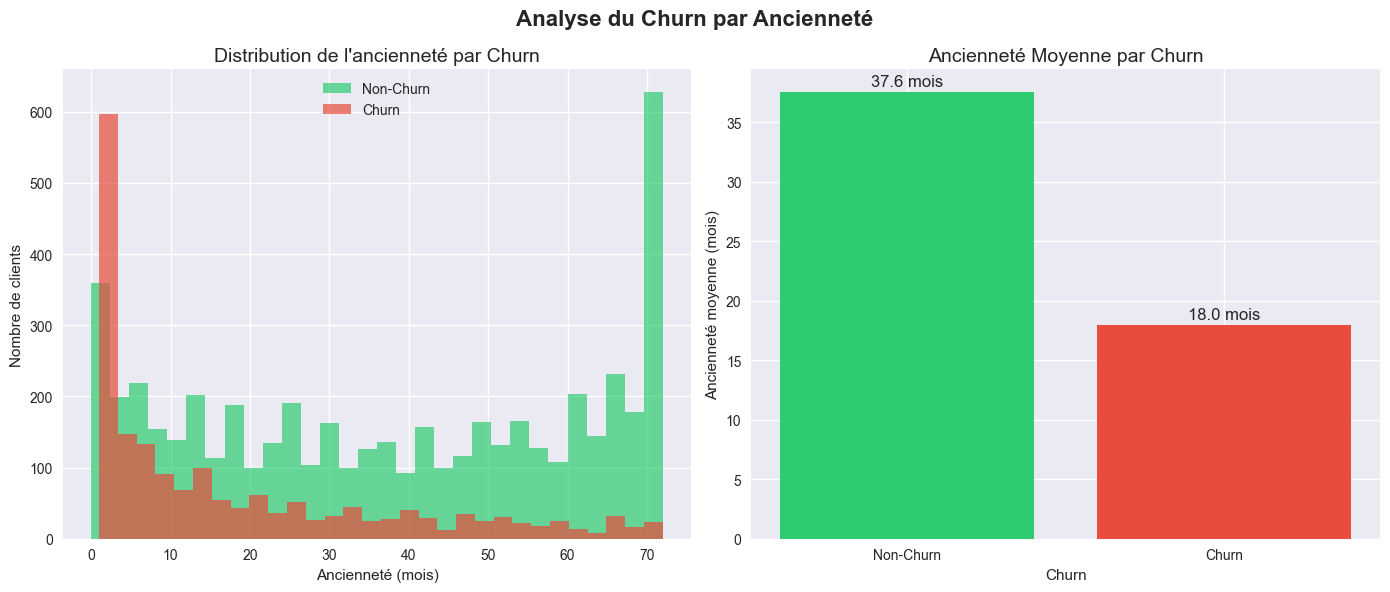


 Ancienneté moyenne des Non-Churners : 37.6 mois
 Ancienneté moyenne des Churners     : 18.0 mois


In [12]:
# =============================================================
# CHURN PAR ANCIENNETÉ (TENURE)
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : distribution de l'ancienneté par churn
axes[0].hist(df[df['Churn'] == 'No']['tenure'], 
             bins=30, alpha=0.7, color='#2ecc71', label='Non-Churn')
axes[0].hist(df[df['Churn'] == 'Yes']['tenure'], 
             bins=30, alpha=0.7, color='#e74c3c', label='Churn')
axes[0].set_title('Distribution de l\'ancienneté par Churn', fontsize=14)
axes[0].set_xlabel('Ancienneté (mois)')
axes[0].set_ylabel('Nombre de clients')
axes[0].legend()

# Graphique 2 : ancienneté moyenne par churn
tenure_moyen = df.groupby('Churn')['tenure'].mean()
axes[1].bar(['Non-Churn', 'Churn'], 
            tenure_moyen.values,
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Ancienneté Moyenne par Churn', fontsize=14)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Ancienneté moyenne (mois)')
for i, v in enumerate(tenure_moyen.values):
    axes[1].text(i, v + 0.5, f'{v:.1f} mois', ha='center', fontsize=12)

plt.suptitle('Analyse du Churn par Ancienneté', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Ancienneté moyenne des Non-Churners : {tenure_moyen['No']:.1f} mois")
print(f" Ancienneté moyenne des Churners     : {tenure_moyen['Yes']:.1f} mois")

Le graphique de gauche montre un pic énorme de churn dans les premiers mois, donc les nouveaux clients sont les plus à risque. Plus un client reste longtemps, moins il a de chances de partir car on voit que les clients fidèles depuis 5-6 ans (70 mois) ne partent presque jamais.

Les 3-6 premiers mois sont critiques. C'est là qu'il faut que l'entreprise concentre les efforts de rétention, peut etre bien accueillir les nouveaux clients, les accompagner, leur montrer la valeur du service...

##  7. Churn par Charges Mensuelles

On analyse si le prix influence le départ des clients.
Est-ce que les clients qui paient plus cher partent davantage ?

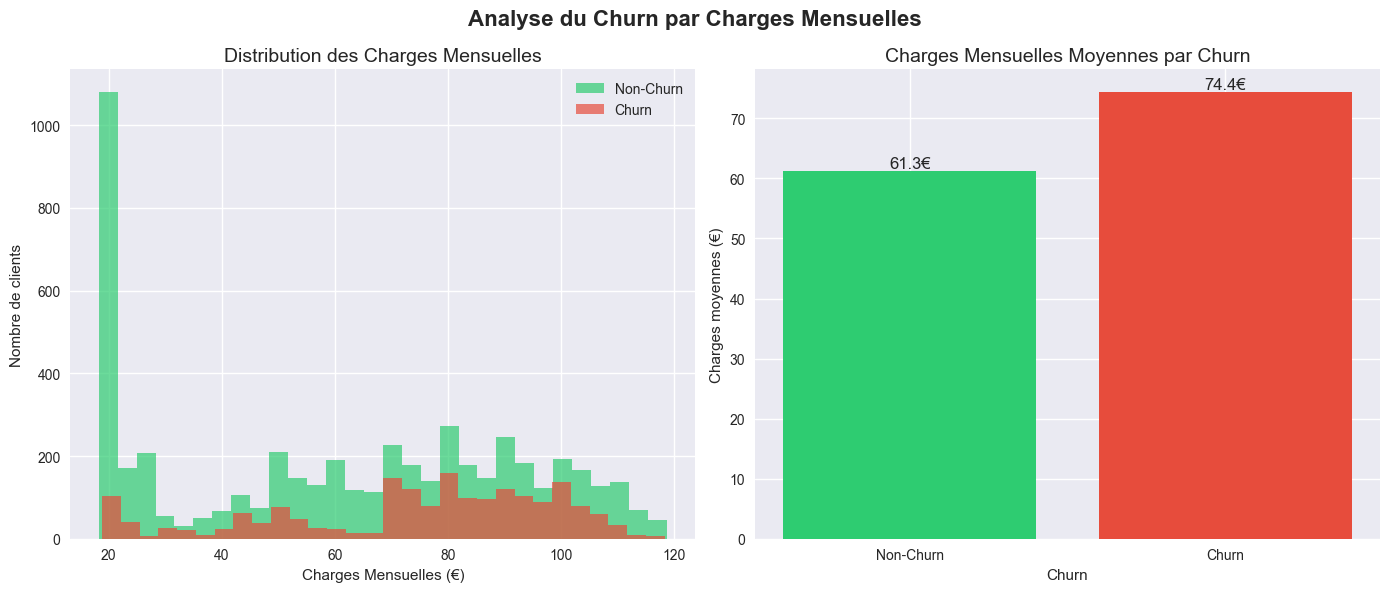


 Charges moyennes des Non-Churners : 61.3€
 Charges moyennes des Churners     : 74.4€


In [15]:
# =============================================================
# CHURN PAR CHARGES MENSUELLES
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : distribution des charges par churn
axes[0].hist(df[df['Churn'] == 'No']['MonthlyCharges'],
             bins=30, alpha=0.7, color='#2ecc71', label='Non-Churn')
axes[0].hist(df[df['Churn'] == 'Yes']['MonthlyCharges'],
             bins=30, alpha=0.7, color='#e74c3c', label='Churn')
axes[0].set_title('Distribution des Charges Mensuelles', fontsize=14)
axes[0].set_xlabel('Charges Mensuelles (€)')
axes[0].set_ylabel('Nombre de clients')
axes[0].legend()

# Graphique 2 : charges moyennes par churn
charges_moyennes = df.groupby('Churn')['MonthlyCharges'].mean()
axes[1].bar(['Non-Churn', 'Churn'],
            charges_moyennes.values,
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Charges Mensuelles Moyennes par Churn', fontsize=14)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Charges moyennes (€)')
for i, v in enumerate(charges_moyennes.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}€', ha='center', fontsize=12)

plt.suptitle('Analyse du Churn par Charges Mensuelles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Charges moyennes des Non-Churners : {charges_moyennes['No']:.1f}€")
print(f" Charges moyennes des Churners     : {charges_moyennes['Yes']:.1f}€")

Les clients qui partent paient en moyenne 13€ de plus par mois. De plus le graphique de gauche montre que les Non-Churners se concentrent surtout autour de 20€ (offre basique) tandis que les Churners sont plus répartis sur les tarifs élevés.
Les clients qui paient cher ont l'impression de ne pas en avoir pour leur argent donc ils partent.

Les clients avec des tarifs élevés sont les plus à risque. L'entreprise devrait peut etre leur proposer des avantages supplémentaires ou des réductions pour les retenir.

##  8. Churn par Services Souscrits

On analyse si le nombre et le type de services souscrits
influencent le départ des clients.

Les services disponibles :
- **PhoneService** : Service téléphonique
- **InternetService** : Type de connexion internet
- **OnlineSecurity** : Sécurité en ligne
- **OnlineBackup** : Sauvegarde en ligne
- **DeviceProtection** : Protection des appareils
- **TechSupport** : Support technique
- **StreamingTV** : Streaming TV
- **StreamingMovies** : Streaming Films

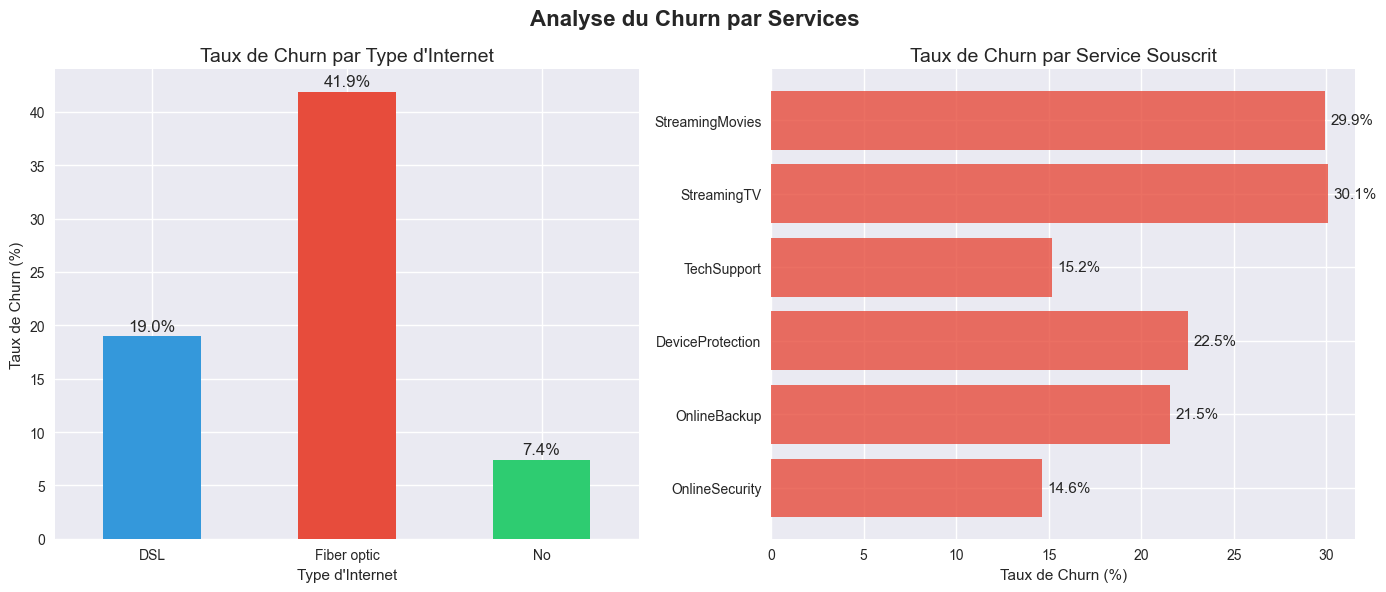


 Taux de churn par type d'internet :
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Yes, dtype: float64


In [16]:
# =============================================================
# CHURN PAR TYPE D'INTERNET SERVICE
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : Churn par type d'internet
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
internet_churn['Yes'].plot(kind='bar',
                           ax=axes[0],
                           color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Taux de Churn par Type d\'Internet', fontsize=14)
axes[0].set_xlabel('Type d\'Internet')
axes[0].set_ylabel('Taux de Churn (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(internet_churn['Yes']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

# Graphique 2 : Churn par services de sécurité/support
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies']

taux_churn_services = []
for service in services:
    taux = df[df[service] == 'Yes']['Churn'].value_counts(normalize=True)['Yes'] * 100
    taux_churn_services.append(taux)

axes[1].barh(services, taux_churn_services, color='#e74c3c', alpha=0.8)
axes[1].set_title('Taux de Churn par Service Souscrit', fontsize=14)
axes[1].set_xlabel('Taux de Churn (%)')
for i, v in enumerate(taux_churn_services):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=11)

plt.suptitle('Analyse du Churn par Services', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Taux de churn par type d'internet :")
print(internet_churn['Yes'].round(1))

Le premier graphique montre que presque 1 client sur 2 ayant la fibre part et le deuxième graphique montre que plus de 1/4 des clients ayant un abonnement de streaming(film et TV) part aussi. Par contre le support technique et la securité fidélise leurs clients.

La Fibre est chère mais déçoit visiblement les clients probablement pour un problème de qualité/prix mais les clients avec TechSupport et OnlineSecurity partent moins, ce qui veut peut etre dire que ces services créent de la valeur et de la fidélité. L'entreprise devrait pousser ces services auprès des clients à risque.

##  9. Churn par Démographie

On analyse l'impact du genre, du statut marital
et des personnes à charge sur le churn.

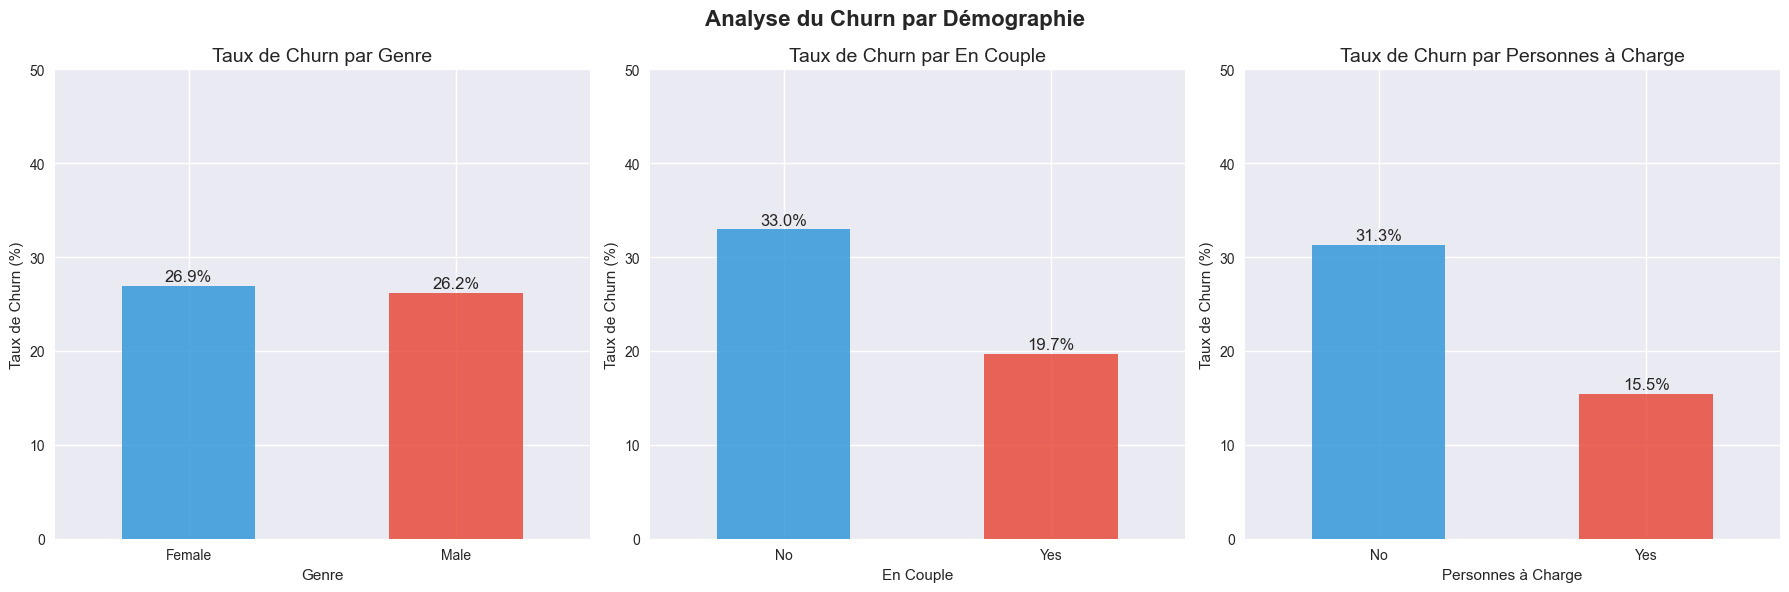

 Taux de churn par démographie :

Genre :
gender
Female    26.9
Male      26.2
Name: Yes, dtype: float64

En Couple :
Partner
No     33.0
Yes    19.7
Name: Yes, dtype: float64

Personnes à Charge :
Dependents
No     31.3
Yes    15.5
Name: Yes, dtype: float64


In [17]:
# =============================================================
# CHURN PAR DÉMOGRAPHIE
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Variables démographiques à analyser
variables = ['gender', 'Partner', 'Dependents']
titres = ['Genre', 'En Couple', 'Personnes à Charge']

for i, (var, titre) in enumerate(zip(variables, titres)):
    # Calcul du taux de churn par catégorie
    churn_var = df.groupby(var)['Churn'].value_counts(normalize=True).unstack() * 100
    
    # Graphique en barres
    churn_var['Yes'].plot(kind='bar',
                          ax=axes[i],
                          color=['#3498db', '#e74c3c'],
                          alpha=0.85)
    axes[i].set_title(f'Taux de Churn par {titre}', fontsize=14)
    axes[i].set_xlabel(titre)
    axes[i].set_ylabel('Taux de Churn (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].set_ylim(0, 50)
    
    # Afficher les pourcentages sur les barres
    for j, v in enumerate(churn_var['Yes']):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

plt.suptitle('Analyse du Churn par Démographie', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé chiffré
print(" Taux de churn par démographie :")
for var, titre in zip(variables, titres):
    churn_var = df.groupby(var)['Churn'].value_counts(normalize=True).unstack() * 100
    print(f"\n{titre} :")
    print(churn_var['Yes'].round(1))

Il n'y a quasiment aucune différence, le genre n'influence probablement pas le churn. Par contre les célibataires partent beaucoup plus, il est plausible que les personnes en couple aient des forfaits partagés donc relativement moins cher. De meme, les clients avec famille partent 2 fois moins.

##  10. Conclusions Générales de l'EDA

### Facteurs les plus liés au Churn :

| Facteur | Observation | Impact |
|---------|-------------|--------|
| **Type de contrat** | Month-to-month = 42.7% churn | 🔴 Très élevé |
| **Internet Fiber optic** | 41.9% churn | 🔴 Très élevé |
| **Ancienneté** | Nouveaux clients très à risque | 🔴 Très élevé |
| **Célibataire** | 33% churn vs 19.7% en couple | 🟡 Élevé |
| **Charges mensuelles** | Churners paient 13€ de plus | 🟡 Élevé |
| **StreamingTV/Movies** | ~30% churn | 🟡 Élevé |
| **Sans dépendants** | 31.3% vs 15.5% avec famille | 🟡 Élevé |
| **TechSupport** | Seulement 15% churn | 🟢 Protecteur |
| **OnlineSecurity** | Seulement 14.6% churn | 🟢 Protecteur |
| **Genre** | 26.9% F vs 26.2% H | ⚪ Aucun impact |

### Actions recommandées :
1. **Cibler** les clients Month-to-month avec des offres de fidélisation
2. **Améliorer** la qualité/prix de la Fibre
3. **Accompagner** les nouveaux clients dans les 6 premiers mois
4. **Promouvoir** TechSupport et OnlineSecurity comme outils de rétention
5. **Créer** des offres spéciales pour les clients célibataires sans dépendants

### Prochaine étape :
 Feature Engineering et entraînement du modèle XGBoost